In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('amazon_clean_data.csv')

In [3]:
df.shape

(1465, 17)

In [4]:
df.drop('user_id', axis = 1, inplace = True)


In [5]:
df.drop('user_name', axis = 1, inplace = True)

In [6]:
df.drop('review_id', axis = 1, inplace = True)
df.drop('img_link', axis = 1, inplace = True)
df.drop('product_link', axis = 1, inplace = True)

In [7]:
df.drop('product_id', axis = 1, inplace = True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         1465 non-null   object 
 1   category             1465 non-null   object 
 2   discounted_price     1465 non-null   float64
 3   actual_price         1465 non-null   float64
 4   discount_percentage  1465 non-null   object 
 5   rating               1465 non-null   float64
 6   rating_count         1463 non-null   float64
 7   about_product        1465 non-null   object 
 8   review_title         1465 non-null   object 
 9   review_content       1465 non-null   object 
 10  discount             1465 non-null   float64
dtypes: float64(5), object(6)
memory usage: 126.0+ KB


In [9]:
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').astype(float)


In [10]:
df['rating_count'].fillna(df['rating_count'].median(), inplace=True)

In [11]:
threshold = df['rating_count'].quantile(0.20)
df['low_selling'] = df['rating_count'] < threshold
df['low_selling'].unique()

array([ True, False])

In [12]:
df['low_selling'] = df['rating_count'] < df['rating_count'].median()

In [13]:
df['price_diff'] = df['actual_price'] - df['discounted_price']

In [14]:
df['desc_length'] = df['about_product'].apply(lambda x: len(x.split()))

In [15]:
df.groupby('low_selling')[['discounted_price','rating','rating_count','desc_length']].mean()

,discounted_price,rating,rating_count,desc_length
low_selling,,,,
False,3619.654292,4.145913,34879.043597,112.655313
True,2628.938687,4.041450,1608.094391,115.436389


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         1465 non-null   object 
 1   category             1465 non-null   object 
 2   discounted_price     1465 non-null   float64
 3   actual_price         1465 non-null   float64
 4   discount_percentage  1465 non-null   float64
 5   rating               1465 non-null   float64
 6   rating_count         1465 non-null   float64
 7   about_product        1465 non-null   object 
 8   review_title         1465 non-null   object 
 9   review_content       1465 non-null   object 
 10  discount             1465 non-null   float64
 11  low_selling          1465 non-null   bool   
 12  price_diff           1465 non-null   float64
 13  desc_length          1465 non-null   int64  
dtypes: bool(1), float64(7), int64(1), object(5)
memory usage: 150.3+ KB


<Axes: >

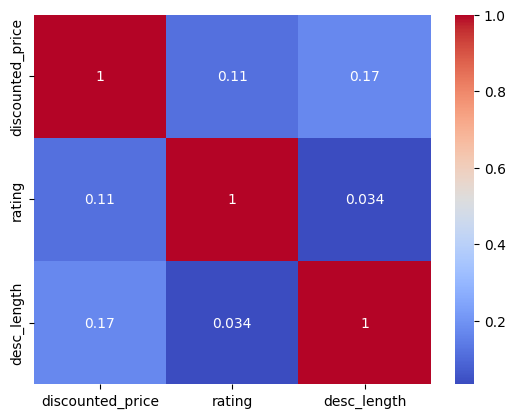

In [17]:
selected_features = ['discounted_price', 'rating', 'desc_length']
sns.heatmap(df[selected_features].corr(), annot=True, cmap='coolwarm')

In [19]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove special chars
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

df['About_prod_clean'] = df['about_product'].apply(clean_text)

In [20]:
df = pd.get_dummies(df, columns=['category'], drop_first=True)

In [21]:
from textblob import TextBlob

df['review_sentiment'] = df['review_content'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [22]:
from gensim.models import Word2Vec

# Tokenize cleaned text
df['tokens'] = df['About_prod_clean'].apply(lambda x: x.split())

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10
)
print('Word2Vec model trained. Vocabulary size:', len(w2v_model.wv))

Word2Vec model trained. Vocabulary size: 13054


In [24]:
def get_avg_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(vector_size)

w2v_vectors = np.array([get_avg_vector(tokens, w2v_model) for tokens in df['tokens']])
w2v_df = pd.DataFrame(w2v_vectors, columns=[f'w2v_{i}' for i in range(100)])
print('Word2Vec feature matrix shape:', w2v_df.shape)

Word2Vec feature matrix shape: (1465, 100)


In [25]:
df_final = pd.concat([df.reset_index(drop=True), w2v_df], axis=1)

In [26]:
df_final.drop(
    ['about_product', 'About_prod_clean', 'review_content', 'review_title', 'tokens'],
    axis=1,
    inplace=True
)

In [27]:
FEATURES = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'discount',
    'price_diff',
    'desc_length',
    'review_sentiment',
]

X = df[FEATURES]
y = df['low_selling']
print('X shape:', X.shape, '| y shape:', y.shape)

X shape: (1465, 8) | y shape: (1465,)


In [28]:
X.drop('category_Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters', axis=1, inplace=True, errors='ignore')

/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/ipykernel_15341/720880180.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('category_Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters', axis=1, inplace=True, errors='ignore')


In [29]:
X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets', axis=1, inplace=True, errors='ignore')
X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones', axis=1, inplace=True, errors='ignore')
X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers', axis=1, inplace=True, errors='ignore')

/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/ipykernel_15341/315435984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets', axis=1, inplace=True, errors='ignore')
/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/ipykernel_15341/315435984.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones', axis=1, inplace=True, errors='ignore')
/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/ipykernel_15341/315435984.py:3: SettingWithC

In [30]:
X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|Webcams&VoIPEquipment|Webcams', axis=1, inplace=True, errors='ignore')
X.drop('category_Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors', axis=1, inplace=True, errors='ignore')
X.drop('category_Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|DVICables', axis=1, inplace=True, errors='ignore')

/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/ipykernel_15341/4289405133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|Webcams&VoIPEquipment|Webcams', axis=1, inplace=True, errors='ignore')
/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/ipykernel_15341/4289405133.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('category_Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors', axis=1, inplace=True, errors='ignore')
/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/ipykernel_15341

In [31]:
X.head()

,discounted_price,actual_price,discount_percentage,rating,discount,price_diff,desc_length,review_sentiment
0,219.0,499.0,56.0,4.4,280.0,280.0,51,0.333333
1,6999.0,16990.0,59.0,3.8,9991.0,9991.0,166,0.508333
2,263.0,699.0,62.0,4.1,436.0,436.0,221,0.353431
3,1999.0,7990.0,75.0,3.8,5991.0,5991.0,151,0.315837
4,199.0,1899.0,90.0,3.9,1700.0,1700.0,163,0.600000


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (1172, 8) | Test: (293, 8)


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])

pipeline.fit(X_train, y_train)
print('Pipeline trained successfully')

Pipeline trained successfully


In [34]:
import joblib
import shap
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# ── Evaluate ──────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Good Sales', 'Low Selling']))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

# ── SHAP: explain one sample ──────────────────────────────────────
scaler   = pipeline.named_steps['scaler']
rf_model = pipeline.named_steps['rf']

sample_raw    = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample_raw)

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(sample_scaled)

# Class-1 (Low Selling) SHAP values
sv = np.array(shap_values[1]).flatten() if isinstance(shap_values, list) \
     else np.array(shap_values).reshape(-1, len(FEATURES), 2)[0, :, 1]

# Top-3 contributors
top3 = sorted(zip(FEATURES, sv), key=lambda x: abs(x[1]), reverse=True)[:3]
print('\nTop-3 SHAP contributors (Low Selling):')
for feat, val in top3:
    print(f'  {feat:<25} SHAP = {val:+.4f}')

# ── Save pipeline ─────────────────────────────────────────────────
joblib.dump(pipeline, 'pipeline.pkl')
print('\nPipeline saved → pipeline.pkl')

              precision    recall  f1-score   support

  Good Sales       0.67      0.69      0.68       147
 Low Selling       0.68      0.66      0.67       146

    accuracy                           0.68       293
   macro avg       0.68      0.68      0.68       293
weighted avg       0.68      0.68      0.68       293

Accuracy: 0.6758

Top-3 SHAP contributors (Low Selling):
  discounted_price          SHAP = +0.0960
  discount_percentage       SHAP = +0.0874
  actual_price              SHAP = +0.0395

Pipeline saved → pipeline.pkl


/Users/priyanka/Desktop/ML/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
import joblib
joblib.dump(pipeline, "pipeline.pkl")

['pipeline.pkl']